# Exploracion del corpus

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.scraper import civitatis_scraper

df = pd.read_csv("../data/resenas_unidas copy 2.csv", sep = ';')
print(len(df))
df.head(2)

2691


,business_name,total_reviews,review_rating,review_text,datetime_utc,pais
0,Visita guiada por el Museo del Prado y el Pala...,1647,5,"La experiencia fue excelente, desde mucho ante...",07/08/2026,ESP
1,Visita guiada por el Museo del Prado y el Pala...,1647,5,Nuestro guía Juan Antonio tenía una gran exper...,07/02/2026,ESP


## Extraccion de mas reseñas

In [ ]:
prado2 = civitatis_scraper(ciudad='madrid', tour='entrada-museo-prado', max_pgs=35)
palacio2 = civitatis_scraper(ciudad='madrid', tour='palacio-real-catedral-almudena', max_pgs=45)
#prado2.to_csv("../data/prado2.csv", sep=';', index=0)
#palacio2.to_csv("../data/palacio2.csv", sep=';', index=0)

Extrayendo datos de la página 1...
Extrayendo datos de la página 2...
Extrayendo datos de la página 3...
Extrayendo datos de la página 4...
Extrayendo datos de la página 5...
Extrayendo datos de la página 6...
Extrayendo datos de la página 7...
Extrayendo datos de la página 8...
Extrayendo datos de la página 9...
Extrayendo datos de la página 10...
Extrayendo datos de la página 11...
Extrayendo datos de la página 12...
Extrayendo datos de la página 13...
Extrayendo datos de la página 14...
Extrayendo datos de la página 15...
Extrayendo datos de la página 16...
Extrayendo datos de la página 17...
Extrayendo datos de la página 18...
Extrayendo datos de la página 19...
Extrayendo datos de la página 20...
Extrayendo datos de la página 21...
Extrayendo datos de la página 22...
Extrayendo datos de la página 23...
Extrayendo datos de la página 24...
Extrayendo datos de la página 25...
Extrayendo datos de la página 26...
Extrayendo datos de la página 27...
Extrayendo datos de la página 28...
E

In [51]:
# palacio2 = palacio2.drop(columns='url_fuente')
# prado2 = prado2.drop(columns='url_fuente')

ninios = pd.read_csv('../data/museo_ninos.csv', sep=';')
ninios['pais'] = 'CR'

df_full = pd.concat([df, palacio2, prado2, ninios])
df_full = df_full[~df_full['business_name'].isin(
    ['Ruinas de la Parroquia de Santiago Apóstol', 'Parque Nacional Manuel Antonio']
)]

df_full.to_csv('../data/5k_resenias.csv', sep=';', index=0)
len(df_full)

5213

## Visualizaciones

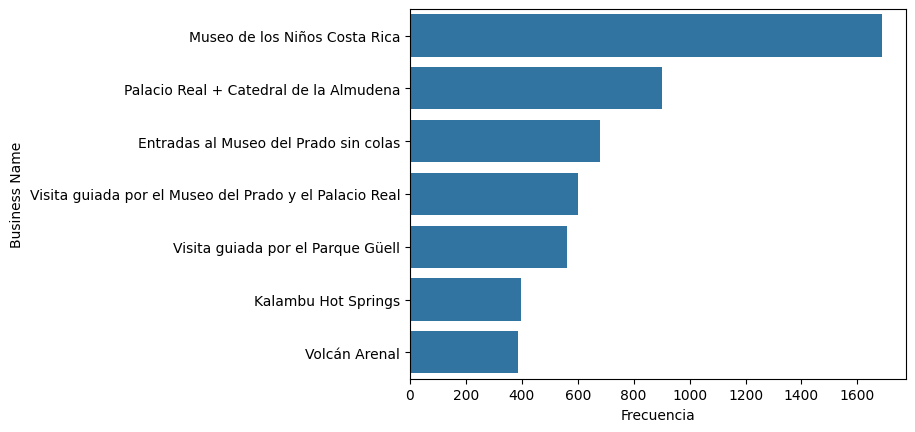

In [ ]:
counts = df_full["business_name"].value_counts()
sns.barplot(x=counts.values, y=counts.index)
plt.xlabel("Frecuencia")
plt.ylabel("Business Name")
plt.show()

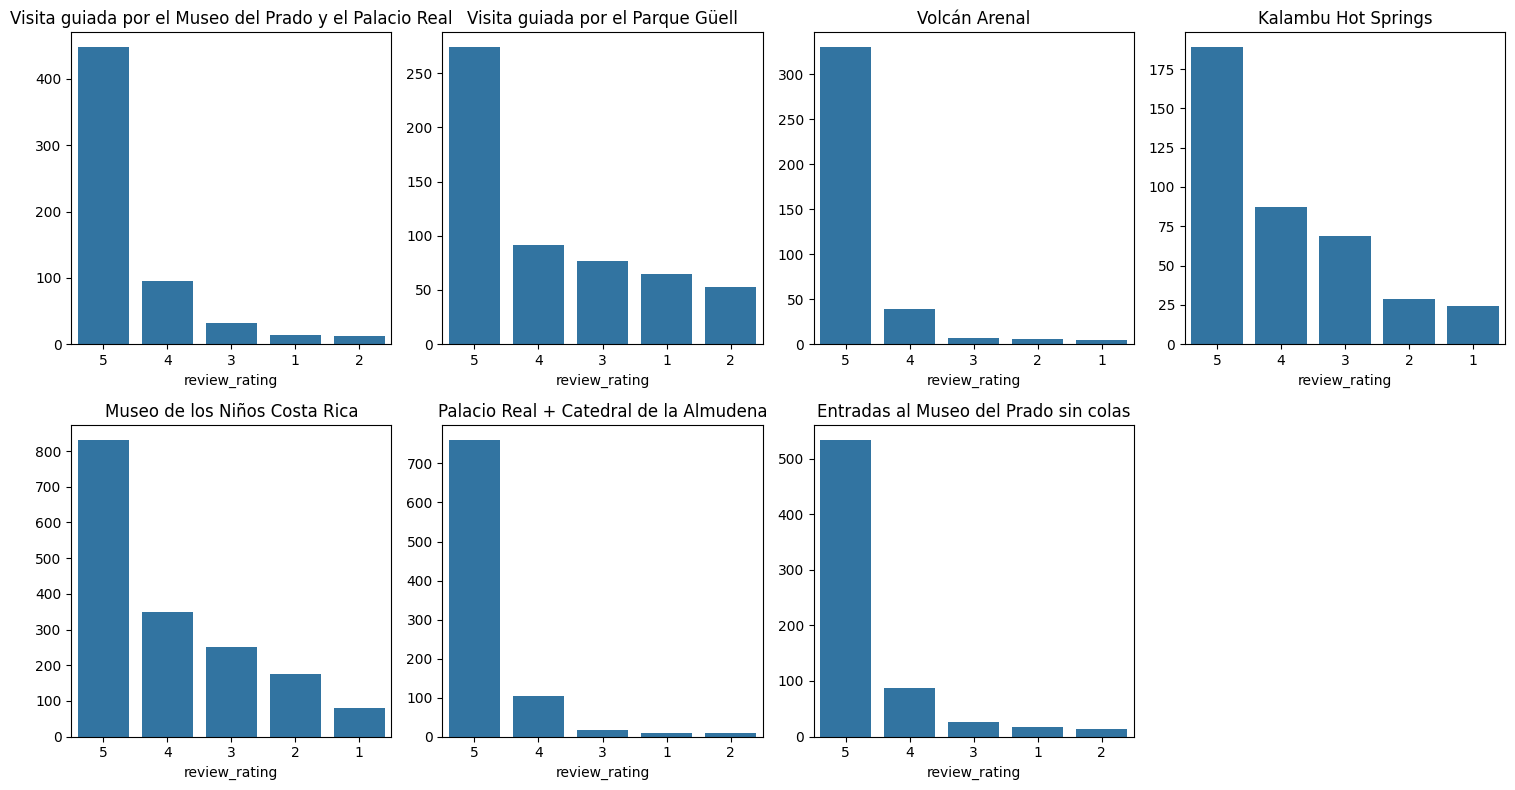

In [49]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for ax, lugar in zip(axes, df_full['business_name'].unique()):
    data = df_full[df_full['business_name'] == lugar]['review_rating'].value_counts()
    sns.barplot(x=data.index.astype(str), y=data.values, ax=ax)
    ax.set_title(lugar)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

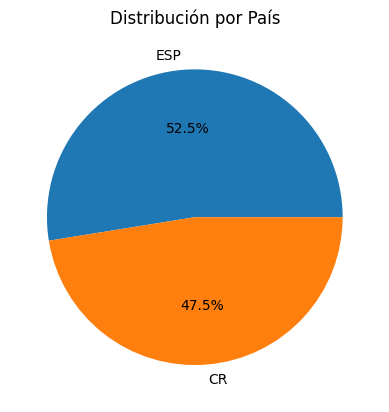

In [45]:
pais_counts = df_full["pais"].value_counts()
plt.pie(pais_counts, labels=pais_counts.index, autopct='%1.1f%%')
plt.title("Distribución por País")
plt.show()